In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=e212a112941fec813adf9b4a5a5832f6962534ee5460ec4009389b314b50fad5
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [ ]:
pip install gtts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.8 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1


In [ ]:
!pip install unrar

In [ ]:
!pip install transformers nltk

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/projet_deeplearning.zip -d  /content/projet_deeplearning

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/projet_deeplearning/Images/2844846111_8c1cbfc75d.jpg  
  inflating: /content/projet_deeplearning/Images/2844963839_ff09cdb81f.jpg  
  inflating: /content/projet_deeplearning/Images/2845246160_d0d1bbd6f0.jpg  
  inflating: /content/projet_deeplearning/Images/2845691057_d4ab89d889.jpg  
  inflating: /content/projet_deeplearning/Images/2845845721_d0bc113ff7.jpg  
  inflating: /content/projet_deeplearning/Images/2846037553_1a1de50709.jpg  
  inflating: /content/projet_deeplearning/Images/2846785268_904c5fcf9f.jpg  
  inflating: /content/projet_deeplearning/Images/2846843520_b0e6211478.jpg  
  inflating: /content/projet_deeplearning/Images/2847514745_9a35493023.jpg  
  inflating: /content/projet_deeplearning/Images/2847615962_c330bded6e.jpg  
  inflating: /content/projet_deeplearning/Images/2847859796_4d9cb0d31f.jpg  
  inflating: /content/projet_deeplearning/Images/2848266893_9693c66275.jpg 

In [ ]:
# Directory and progress handling
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm

# Handle warnings
import warnings
warnings.filterwarnings('ignore')

# Data visulization
from PIL import Image
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# listen to predicted text
from gtts import gTTS


# Text and Image proceesing and modeling
import nltk
import tensorflow as tf
from nltk.corpus import stopwords
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.applications import ResNet50, MobileNetV3Large
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v3  import preprocess_input
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add,Bidirectional
from tensorflow.keras.layers import BatchNormalization, RepeatVector, Dot, Activation,Concatenate
from tensorflow.keras.optimizers import Adam

In [ ]:
BASE_DIR = '/content/projet_deeplearning'


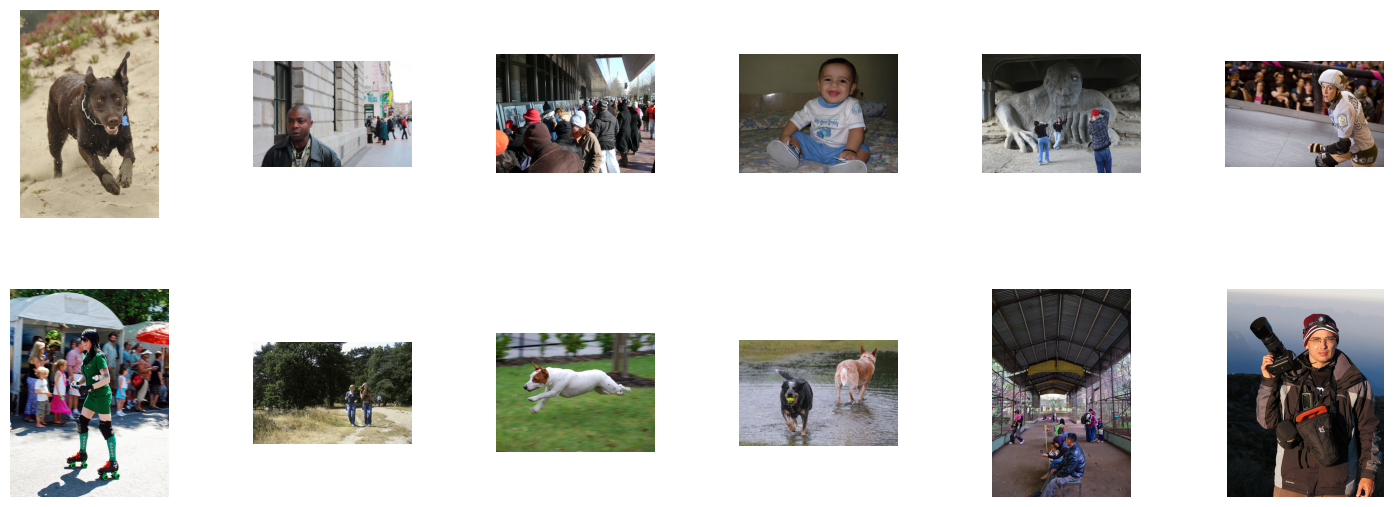

In [ ]:
IMAGES_DIR = os.path.join(BASE_DIR, 'Images')
# List of image filenames
image_filenames = os.listdir(IMAGES_DIR)
# Select 12 images for display
image_filenames = image_filenames[:12]
fig, axes = plt.subplots(2, 6, figsize=(15, 6)) #12 image in 2 rows and 6 columns
fig.tight_layout(pad=3.0)
# Display images without captions
for i, ax in enumerate(axes.flat):
    # Load the image
    img_path = os.path.join(IMAGES_DIR, image_filenames[i])
    img = Image.open(img_path)
    # Display the image
    ax.imshow(img)
    ax.axis('off')  # Hide axes and captions
plt.show()

# L'architecture MobileNetV3Large model

In [ ]:
# load MobileNetV3Large model

model = MobileNetV3Large(weights='imagenet', include_top=True)

model = Model(inputs=model.inputs, outputs=model.layers[-2].output)

# summarize the model for checking the last layer

model.summary()

22661472/22661472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, None,      │        432 │ rescaling[0][0]   │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, None,      │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ conv_bn[0][0]     │
│ (Activation)        │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, None,      │          0 │ expanded_conv_de… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, None,      │          0 │ activation[0][0], │
│ (Add)               │ None, 16)         │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, None,      │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, None,      │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, None,      │          0 │ expanded_conv_1_… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, None,      │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, None,      │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, None,      │        256 │ expanded_conv_1_

 Total params: 5,507,432 (21.01 MB)

 Trainable params: 5,483,032 (20.92 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [ ]:
features = {}
directory = os.path.join(BASE_DIR, 'Images')  # Path to the directory containing images
# Loop through all images in the directory
for img_name in tqdm(os.listdir(directory)):
    # Load the image with the target size of 224x224 (required for ---->MobileNetV3Large<----)
    img_path = os.path.join(directory, img_name)
    image = load_img(img_path, target_size=(224, 224))
    # Convert image to a numpy array
    image = img_to_array(image)
    # Expand dimensions to match the model's expected input shape (1, 224, 224, 3)
    image = np.expand_dims(image, axis=0)
    # Preprocess the image for MobileNetV3Large
    image = preprocess_input(image)
    # Extract features from the second-to-last fully connected layer
    feature = model.predict(image, verbose=0)
    # Get the image ID (filename without extension)
    image_id = img_name.split('.')[0]
    # Store the extracted features in the dictionary
    features[image_id] = feature

  0%|          | 0/8091 [00:00<?, ?it/s]

In [ ]:

dest_path = os.path.join(BASE_DIR, 'features.pkl')
with open(dest_path, 'wb') as f:
    pickle.dump(features, f)

In [ ]:
# load features from pickle, if you have the file you can start from here

with open(dest_path, 'rb') as f:
    features = pickle.load(f)

In [ ]:
# load features from pickle, if you have the file you can start from here
with open(os.path.join(BASE_DIR, 'captions.txt'), 'r') as f:
    # to skip the first row on the captions file
    next(f)
    # read all captions file
    captions_doc = f.read()

In [ ]:
mapping = {}
# process lines
for line in tqdm(captions_doc.split('\n')):
    # split the line by comma
    tokens = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    # remove extension from image ID
    image_id = image_id.split('.')[0]
    # convert caption list to string
    caption = " ".join(caption)
    # create list if image ID will added to the first time
    if image_id not in mapping:
        mapping[image_id] = []
    # store the caption if the image ID already exting in the mapping dict
    mapping[image_id].append(caption)

  0%|          | 0/40456 [00:00<?, ?it/s]

In [ ]:
def clean_captions(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            # take one caption at a time
            caption = captions[i]
            # preprocessing steps
            # convert to lowercase
            caption = caption.lower()
            # delete digits, special chars, etc
            caption = caption.replace('[^A-Za-z]', '')
            # delete additional spaces
            caption = caption.replace('\s+', ' ')
            # add start and end tags to the caption ---> important in text generation
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1]) + ' endseq'
            captions[i] = caption

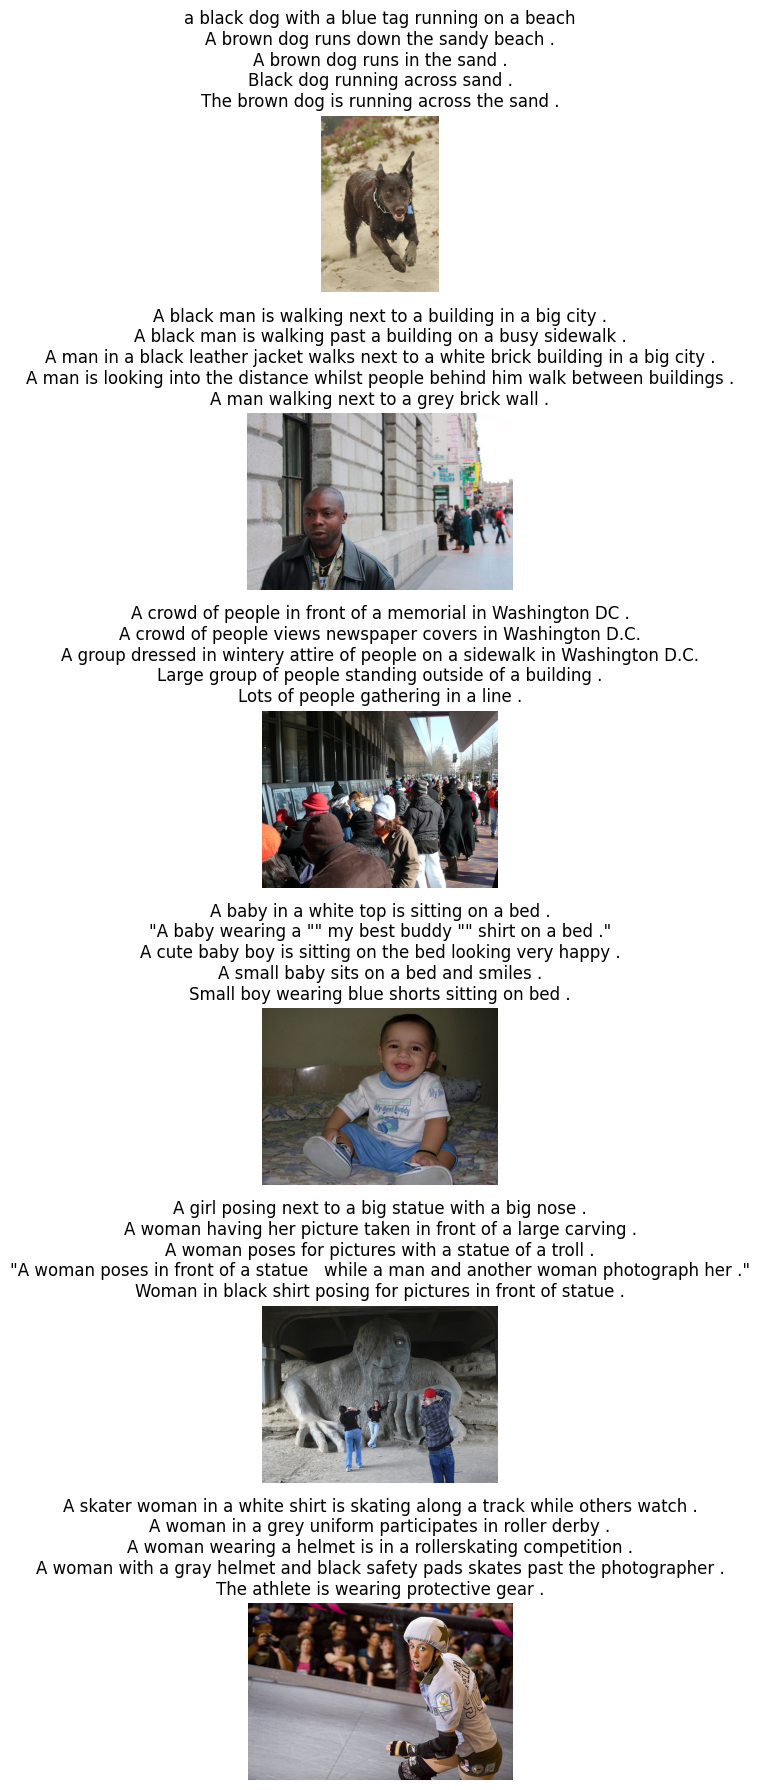

In [ ]:
# after preparing the captions , we will display a sample of the data with captions

def display_images_with_mapping(directory, mapping, num_images=6):
    # Get all image filenames from the directory
    img_names = os.listdir(directory)[:num_images]  # to get 6 images ..note if you want to display more handle the num of images
    # Create a figure with 6 rows (one for each image) and 1 column
    fig, axes = plt.subplots(num_images, 1, figsize=(10, num_images * 3))

    for i, img_name in enumerate(img_names):
        # Extract image ID by removing file extension
        image_id = img_name.split('.')[0]
        # Ensure the image ID is in the mapping dictionary
        if image_id in mapping:
            # Load the image
            img_path = os.path.join(directory, img_name)
            img = plt.imread(img_path)
        # Plot the image in the corresponding row
            axes[i].imshow(img)
            axes[i].axis('off')  # Hide axis for a cleaner look
            # Get the corresponding captions from the mapping
            captions = mapping[image_id][:5]  # Get the first 5 captions
            caption_text = "\n".join(captions)
            axes[i].set_title(caption_text, fontsize=12)

    # Adjust layout
    plt.tight_layout()
    plt.show()

# Directory containing images
image_directory = os.path.join(BASE_DIR, 'Images')
# Call the function to display images with captions
display_images_with_mapping(image_directory, mapping)

In [ ]:
def clean_captions(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            # take one caption at a time
            caption = captions[i]
            # preprocessing steps
            # convert to lowercase
            caption = caption.lower()
            # delete digits, special chars, etc
            caption = caption.replace('[^A-Za-z]', '')
            # delete additional spaces
            caption = caption.replace('\s+', ' ')
            # add start and end tags to the caption ---> important in text generation
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1]) + ' endseq'
            captions[i] = caption

In [ ]:
all_captions = []

for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


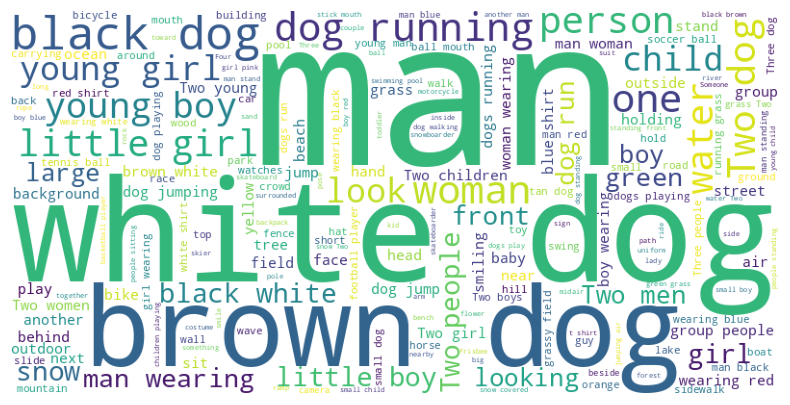

In [ ]:
# the importance of this step to know the most frequant words in your dataset
# Download stopwords
nltk.download('stopwords')

# Remove 'startseq' and 'endseq' from captions
filtered_captions = [caption.replace('startseq', '').replace('endseq', '') for caption in all_captions]

# Combine all captions into one string
all_text = " ".join(filtered_captions)

# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in all_text.split() if word not in stop_words]

# Create a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filtered_words))

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
vocab_size

8494

In [ ]:
with open(os.path.join(BASE_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)

In [ ]:
max_length = max(len(caption.split()) for caption in all_captions)
max_length

37

In [ ]:
# prepare a list of image IDs
image_ids = list(mapping.keys())

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = list(), list(), list()
    n = 0

    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]

                    # Ensure padding is applied properly here
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)

            if n == batch_size:
                yield {"image": np.array(X1), "text": np.array(X2)}, np.array(y)
                X1, X2, y = list(), list(), list()


In [ ]:
#Model Architecture
inputs1 = Input(shape=(1000,),name='image')
fe1 = BatchNormalization()(inputs1)
fe2 = Dense(512, activation='relu')(fe1)
fe2_projected = RepeatVector(max_length)(fe2)

inputs2 = Input(shape=(max_length,), name='text')
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = BatchNormalization()(se1)
se3 = Bidirectional(LSTM(256, return_sequences=True))(se2)

attention = Dot(axes=[2, 2])([fe2_projected, se3])
attention = Activation('softmax')(attention)
context_vector = Dot(axes=[1, 1])([attention, se3])
context_vector = BatchNormalization()(context_vector)


context_vector = tf.keras.layers.Flatten()(context_vector)
decoder1 = Concatenate()([context_vector, fe2])
decoder2 = Dense(512, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
optimizer = Adam(learning_rate=5e-4, clipvalue=5.0)
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=['accuracy'])

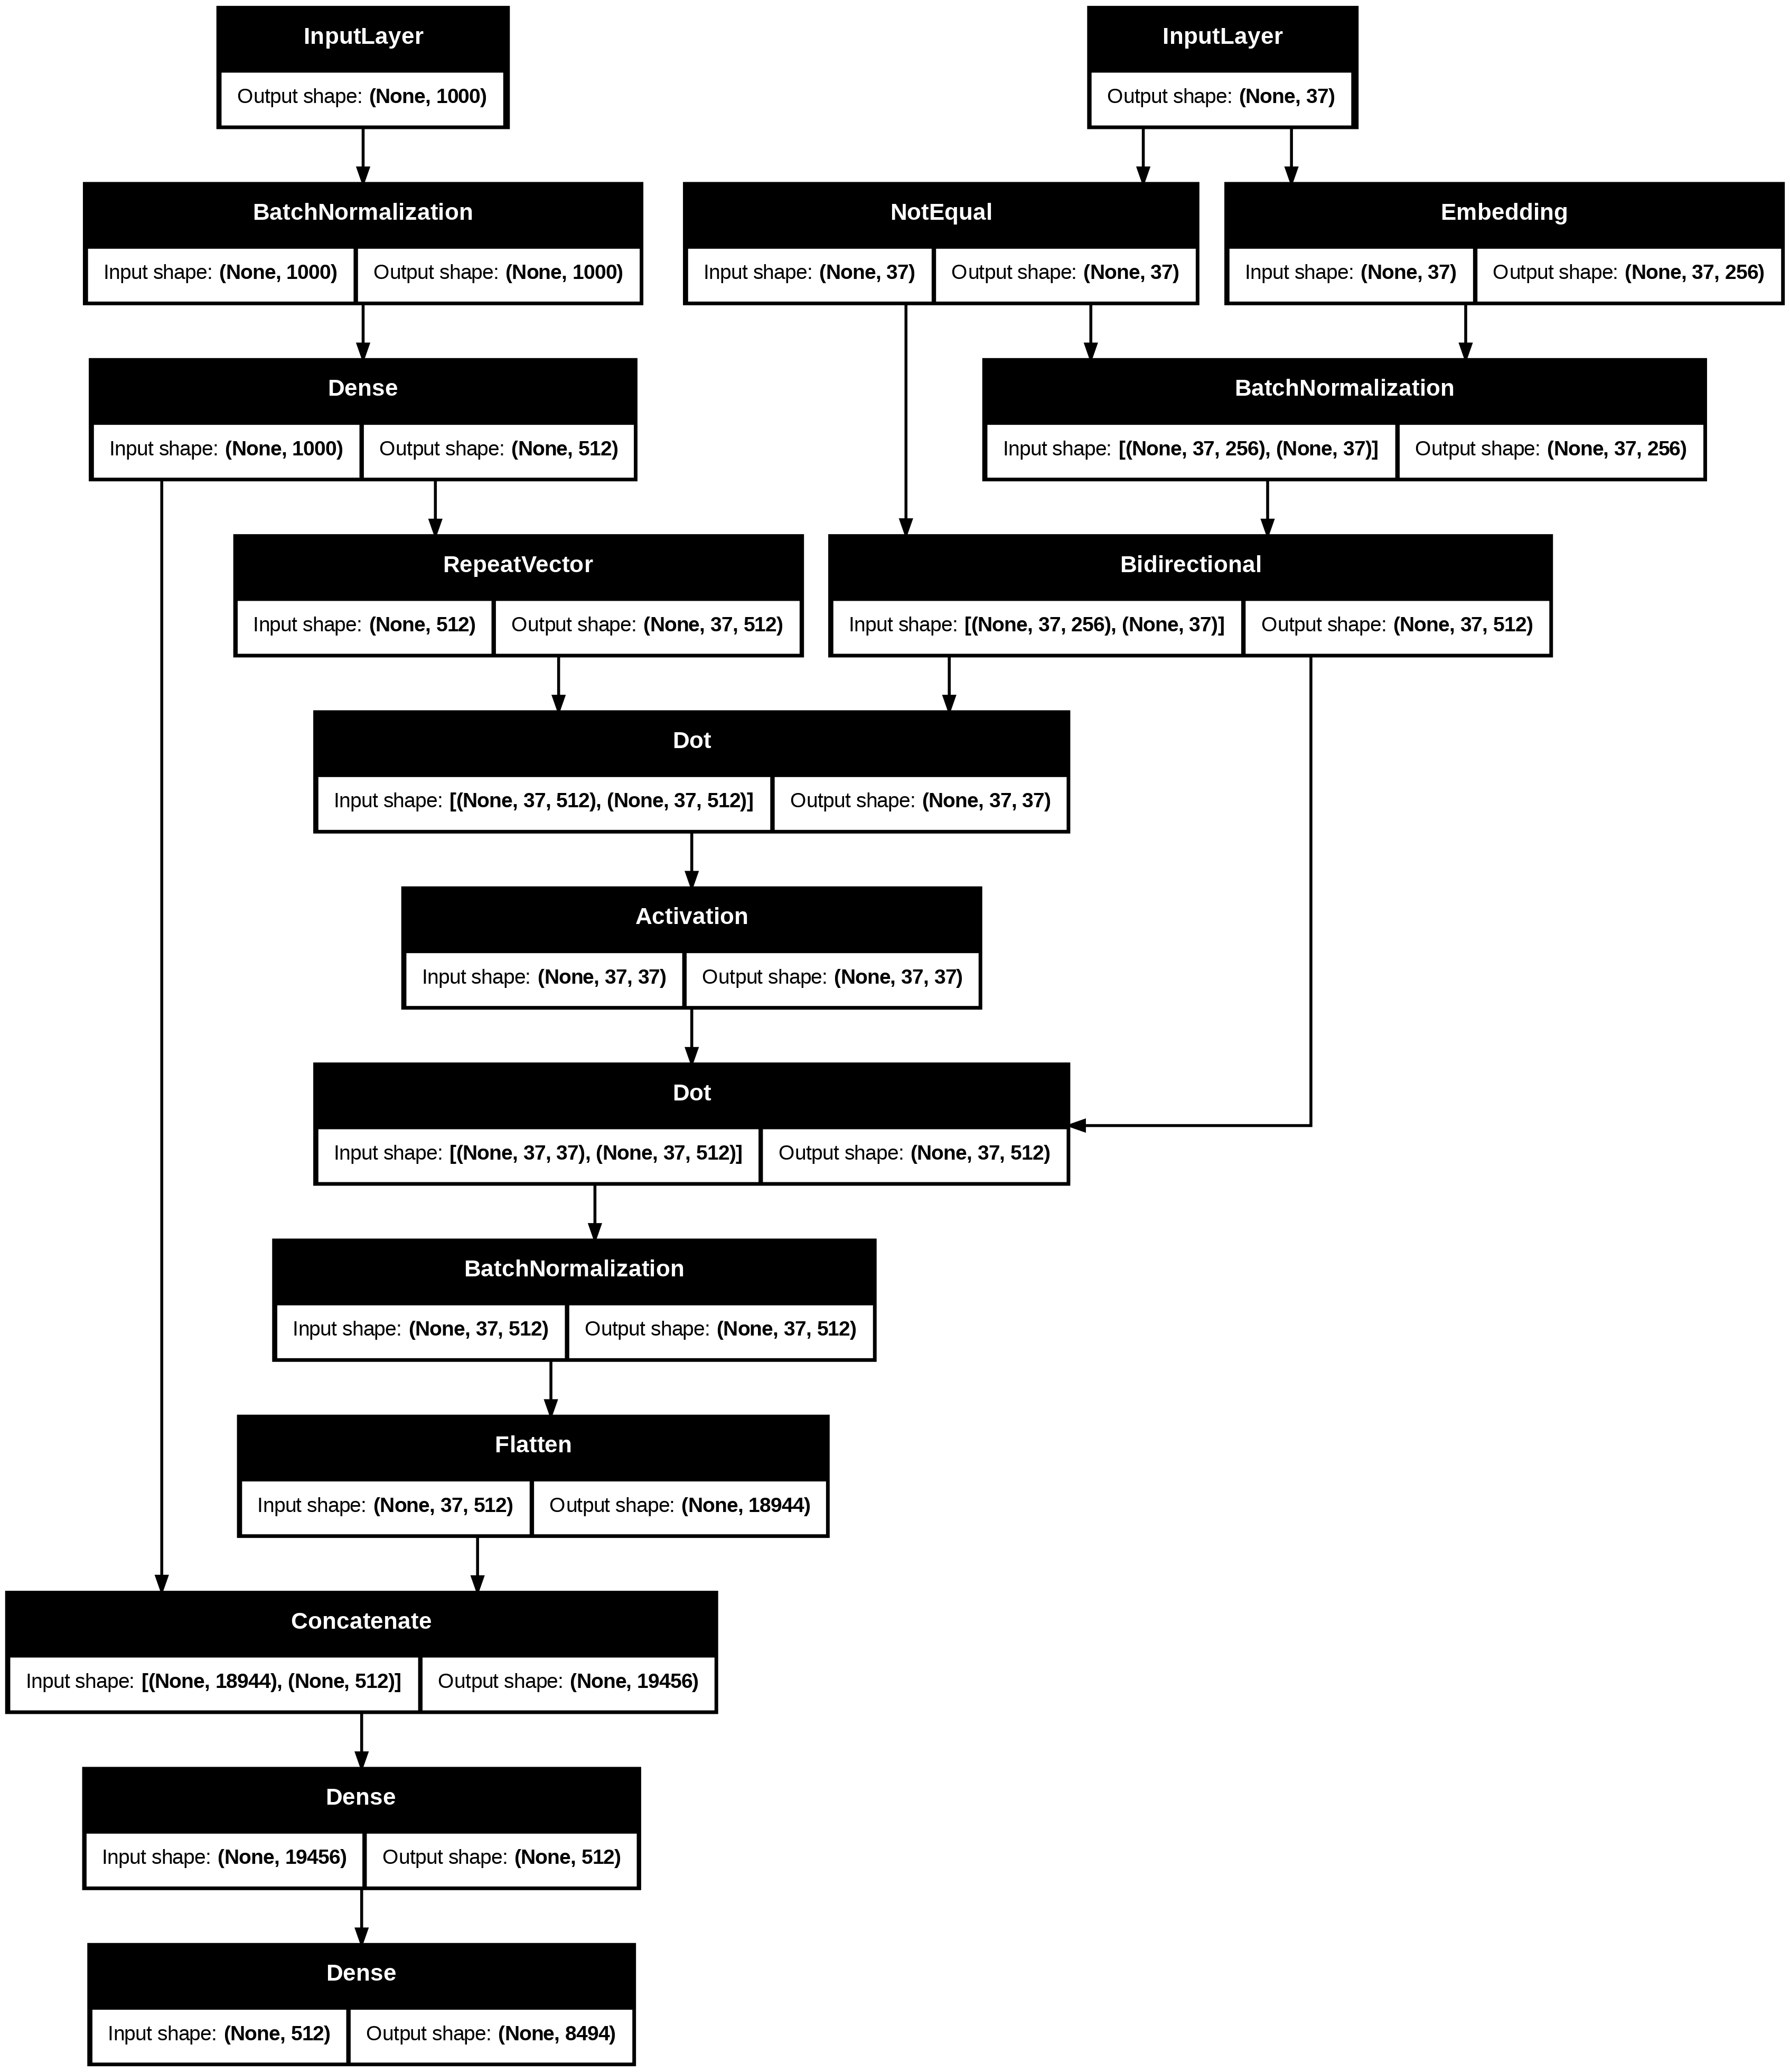

In [ ]:
plot_model(model, show_shapes=True)

In [ ]:


epochs = 20
batch_size = 32
steps = len(image_ids) // batch_size
for i in range(epochs):
    generator = data_generator(image_ids, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)


Evaluation and examples

In [ ]:
# Liste pour stocker les légendes générées et réelles
output_caption_list = []
real_caption_list = []

# Charger les images depuis le répertoire
images_path = os.listdir(os.path.join(BASE_DIR, 'Images'))

# Sélectionner 10 indices d'images aléatoires
image_name_idx = np.random.randint(0, len(images_path), 500)
j=0
# Pour chaque image sélectionnée
for i in image_name_idx:
    # Générer la légende de l'image avec le modèle
    caption = generate_caption(images_path[i],j)
    j+=1
    # Extraire le nom de l'image sans l'extension
    image_name = images_path[i].split('.')[0]

    # Récupérer toutes les légendes réelles de l'image depuis le mapping
    real_captions = mapping[image_name]  # Ce mapping contient 5 légendes pour chaque image

    # Ajouter toutes les légendes réelles (nettoyées) dans real_caption_list
    real_captions_cleaned = [caption.replace('startseq', '').replace('endseq', '').strip() for caption in real_captions]
    real_caption_list.append(real_captions_cleaned)

    # Ajouter la légende générée dans output_caption_list
    output_caption_list.append(caption)




In [ ]:
import evaluate

# Charger la métrique BLEU
bleu = evaluate.load("bleu")

# Calcul des prédictions et des références
predictions = output_caption_list  # Légendes générées par ton modèle
references = real_caption_list  # Légendes réelles (avec 5 légendes pour chaque image)

# Calculer le score BLEU
results = bleu.compute(predictions=predictions, references=references)

# Afficher les résultats
print(f"BLEU score: {results}")

In [ ]:

# Load the ROUGE evaluation metric
import evaluate
rouge = evaluate.load('rouge')

results = rouge.compute(predictions=predictions, references=references)

# Print the results
print(results)

